# Air Quality LSTM Analysis with PyTorch GPU
## Time Series Forecasting for Air Quality Monitoring using PyTorch CUDA

In [2]:
# Import PyTorch and GPU libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import sys
from datetime import datetime, timedelta
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check PyTorch GPU setup
print("🔥 PyTorch GPU Setup")
print("=" * 50)
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    device = torch.device('cuda')
else:
    print("Using CPU")
    device = torch.device('cpu')
print(f"Active Device: {device}")

🔥 PyTorch GPU Setup
PyTorch Version: 2.5.1+cu121
CUDA Available: True
GPU Device: NVIDIA GeForce RTX 2050
GPU Memory: 4.3 GB
Active Device: cuda
CUDA Available: True
GPU Device: NVIDIA GeForce RTX 2050
GPU Memory: 4.3 GB
Active Device: cuda


In [3]:
# Load real air quality data from your feeds.csv
print("📊 Loading Air Quality Data")
print("=" * 50)

# Try to load your real data
data_path = 'data/feeds.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Loaded real data: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    # Map ThingSpeak fields to air quality parameters
    column_mapping = {
        'field1': 'humidity',
        'field2': 'temperature', 
        'field3': 'pm25',
        'field4': 'pm10',
        'created_at': 'timestamp'
    }
    
    # Rename columns
    df.rename(columns=column_mapping, inplace=True)
    
    # Convert timestamp
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df.set_index('timestamp', inplace=True)
    
    print(f"📅 Date range: {df.index.min()} to {df.index.max()}")
    print(f"📊 Total data points: {len(df):,}")
    
else:
    # Create sample data if real data not found
    print("⚠️  Real data not found, creating sample data...")
    n_samples = 5000
    timestamps = pd.date_range(start='2024-01-01', periods=n_samples, freq='h')
    
    np.random.seed(42)
    hours = np.arange(n_samples) % 24
    
    # Realistic patterns
    temperature = 20 + 10 * np.sin(2 * np.pi * hours / 24) + np.random.normal(0, 3, n_samples)
    humidity = 60 + 20 * np.sin(2 * np.pi * hours / 24 + np.pi) + np.random.normal(0, 8, n_samples)
    humidity = np.clip(humidity, 0, 100)
    
    pm25 = 25 + 15 * np.sin(2 * np.pi * hours / 24 + np.pi/3) + np.random.normal(0, 8, n_samples)
    pm25 = np.clip(pm25, 0, 200)
    
    pm10 = pm25 * 1.4 + np.random.normal(0, 5, n_samples)
    pm10 = np.clip(pm10, 0, 300)
    
    df = pd.DataFrame({
        'temperature': temperature,
        'humidity': humidity,
        'pm25': pm25,
        'pm10': pm10
    }, index=timestamps)

# Clean and validate data
features = ['temperature', 'humidity', 'pm25', 'pm10']
df = df[features].dropna()

print(f"🧹 After cleaning: {len(df):,} samples")
print("\n📈 Data Statistics:")
print(df.describe().round(2))

📊 Loading Air Quality Data
✅ Loaded real data: (92528, 10)
Columns: ['created_at', 'entry_id', 'field1', 'field2', 'field3', 'field4', 'latitude', 'longitude', 'elevation', 'status']
📅 Date range: 2025-03-05 03:37:33+00:00 to 2025-04-30 07:28:07+00:00
📊 Total data points: 92,528
🧹 After cleaning: 92,365 samples

📈 Data Statistics:
       temperature  humidity      pm25      pm10
count     92365.00  92365.00  92365.00  92365.00
mean         33.00     35.51     26.53     36.59
std           7.75      3.53     14.96     24.51
min          13.97     21.29      6.20     10.00
25%          27.06     33.19     18.90     25.70
50%          33.08     35.51     23.70     31.60
75%          38.52     38.20     31.40     42.10
max          61.63     43.66    999.90   1999.90


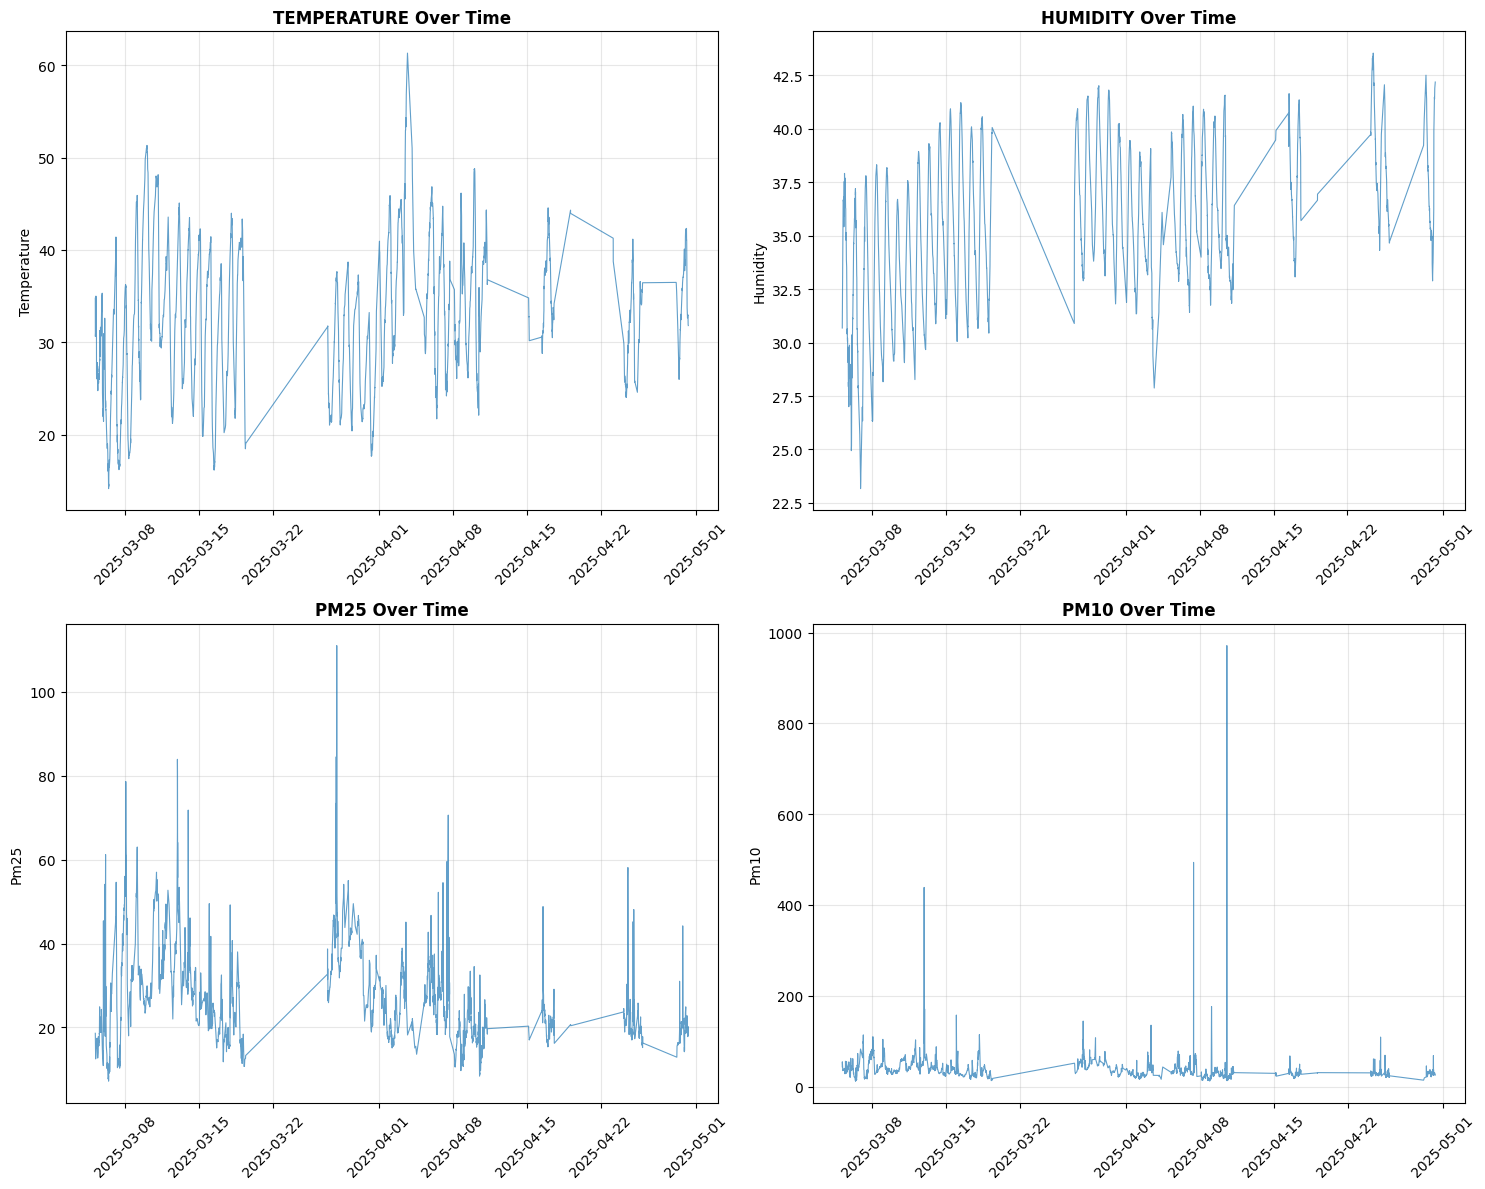

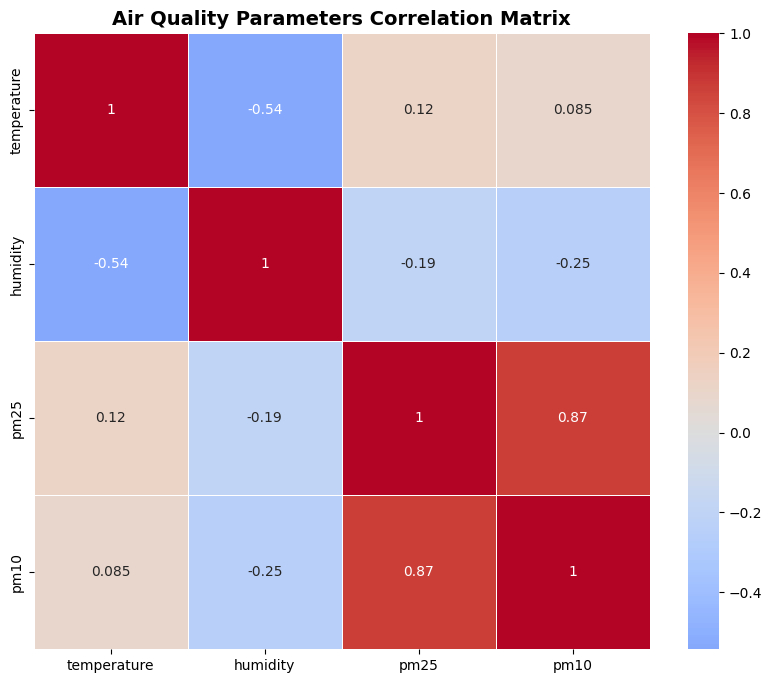

In [4]:
# Data visualization
plt.figure(figsize=(15, 12))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    
    # Plot time series (sample if too many points)
    if len(df) > 2000:
        sample_data = df.sample(2000).sort_index()
        plt.plot(sample_data.index, sample_data[feature], alpha=0.7, linewidth=0.8)
    else:
        plt.plot(df.index, df[feature], alpha=0.8)
    
    plt.title(f'{feature.upper()} Over Time', fontsize=12, fontweight='bold')
    plt.ylabel(feature.replace('_', ' ').title())
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Air Quality Parameters Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

In [5]:
# Define PyTorch LSTM Model for Air Quality Prediction
class AirQualityLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=128, num_layers=3, output_size=4, 
                 dropout=0.3, use_attention=True):
        super(AirQualityLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.use_attention = use_attention
        
        # Input projection
        self.input_projection = nn.Linear(input_size, hidden_size)
        
        # Bidirectional LSTM layers
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
            bidirectional=True
        )
        
        # Multi-head attention
        if use_attention:
            self.attention = nn.MultiheadAttention(
                embed_dim=hidden_size * 2,  # *2 for bidirectional
                num_heads=8,
                dropout=dropout,
                batch_first=True
            )
        
        # Batch normalization
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)
        
        # Dense layers
        self.dense_layers = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights using Xavier initialization"""
        for name, param in self.named_parameters():
            if 'weight' in name and len(param.shape) >= 2:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
    
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        
        # Input projection
        x = self.input_projection(x)
        
        # LSTM forward pass
        lstm_out, _ = self.lstm(x)
        
        # Apply attention if enabled
        if self.use_attention:
            attended_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
            lstm_out = lstm_out + attended_out  # Residual connection
        
        # Get last output
        final_output = lstm_out[:, -1, :]
        
        # Batch normalization (only if batch size > 1)
        if batch_size > 1:
            final_output = self.batch_norm(final_output)
        
        # Dense layers
        output = self.dense_layers(final_output)
        return output

# Model configuration
model_config = {
    'input_size': len(features),
    'hidden_size': 128,
    'num_layers': 3,
    'output_size': len(features),
    'dropout': 0.3,
    'use_attention': True
}

print("🤖 PyTorch LSTM Model Configuration")
print("=" * 50)
for key, value in model_config.items():
    print(f"{key}: {value}")

# Create model and move to GPU
model = AirQualityLSTM(**model_config).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Parameters:")
print(f"Total: {total_params:,}")
print(f"Trainable: {trainable_params:,}")
print(f"Device: {next(model.parameters()).device}")

🤖 PyTorch LSTM Model Configuration
input_size: 4
hidden_size: 128
num_layers: 3
output_size: 4
dropout: 0.3
use_attention: True

📊 Model Parameters:
Total: 1,360,452
Trainable: 1,360,452
Device: cuda:0

📊 Model Parameters:
Total: 1,360,452
Trainable: 1,360,452
Device: cuda:0


In [6]:
# Data preprocessing for LSTM
def create_sequences(data, sequence_length=48, target_features=None):
    """Create sequences for LSTM training"""
    if target_features is None:
        target_features = features
    
    X, y = [], []
    for i in range(len(data) - sequence_length):
        # Input sequence (past 48 hours)
        X.append(data[i:i + sequence_length])
        # Target (next hour values)
        y.append(data[i + sequence_length])
    
    return np.array(X), np.array(y)

# Prepare data
print("🔄 Preparing Data for Training")
print("=" * 50)

sequence_length = 48  # Use 48 hours of history
data_values = df[features].values.astype(np.float32)

# Scale data
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(data_values)
y_scaled = scaler_y.fit_transform(data_values)

print(f"✅ Data scaled to range [0, 1]")
print(f"Input shape: {X_scaled.shape}")

# Create sequences
X_sequences, y_sequences = create_sequences(X_scaled, sequence_length)

print(f"✅ Created sequences")
print(f"Sequence shape: {X_sequences.shape}")
print(f"Target shape: {y_sequences.shape}")

# Train/validation split
split_idx = int(0.8 * len(X_sequences))
X_train = X_sequences[:split_idx]
X_val = X_sequences[split_idx:]
y_train = y_sequences[:split_idx]
y_val = y_sequences[split_idx:]

print(f"✅ Data split:")
print(f"Training: {X_train.shape[0]:,} sequences")
print(f"Validation: {X_val.shape[0]:,} sequences")

# Convert to PyTorch tensors and move to GPU
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

print(f"✅ Tensors moved to {device}")

# Create data loaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"✅ Data loaders created (batch_size: {batch_size})")

🔄 Preparing Data for Training
✅ Data scaled to range [0, 1]
Input shape: (92365, 4)
✅ Created sequences
Sequence shape: (92317, 48, 4)
Target shape: (92317, 4)
✅ Data split:
Training: 73,853 sequences
Validation: 18,464 sequences
✅ Tensors moved to cuda
✅ Data loaders created (batch_size: 64)
✅ Tensors moved to cuda
✅ Data loaders created (batch_size: 64)


In [7]:
# Training configuration and loop
print("🚀 Starting PyTorch LSTM Training on GPU")
print("=" * 50)

# Training parameters
epochs = 100
learning_rate = 0.001
patience = 15

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5)

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

print(f"Training Parameters:")
print(f"  Epochs: {epochs}")
print(f"  Learning Rate: {learning_rate}")
print(f"  Batch Size: {batch_size}")
print(f"  Patience: {patience}")
print(f"  Device: {device}")

# Training loop with GPU acceleration
for epoch in tqdm(range(epochs), desc="Training Progress"):
    # Training phase
    model.train()
    train_loss = 0.0
    train_batches = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()
        train_batches += 1
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            val_batches += 1
    
    # Calculate averages
    avg_train_loss = train_loss / train_batches
    avg_val_loss = val_loss / val_batches
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.6f}, '
              f'Val Loss: {avg_val_loss:.6f}, LR: {current_lr:.6f}')
    
    # Early stopping
    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

print(f'\n✅ Training completed!')
print(f'Best validation loss: {best_val_loss:.6f}')
print(f'Total epochs: {len(train_losses)}')

🚀 Starting PyTorch LSTM Training on GPU
Training Parameters:
  Epochs: 100
  Learning Rate: 0.001
  Batch Size: 64
  Patience: 15
  Device: cuda
Training Parameters:
  Epochs: 100
  Learning Rate: 0.001
  Batch Size: 64
  Patience: 15
  Device: cuda


Training Progress:  10%|█         | 10/100 [04:58<44:37, 29.75s/it]

Epoch [10/100] - Train Loss: 0.000938, Val Loss: 0.000264, LR: 0.001000


Training Progress:  20%|██        | 20/100 [09:57<39:57, 29.97s/it]

Epoch [20/100] - Train Loss: 0.000771, Val Loss: 0.000234, LR: 0.001000


...

Epoch [30/100] - Train Loss: 0.000730, Val Loss: 0.000155, LR: 0.001000


Training Progress:  40%|████      | 40/100 [20:01<30:31, 30.52s/it]

Epoch [40/100] - Train Loss: 0.000678, Val Loss: 0.000275, LR: 0.000500


Training Progress:  43%|████▎     | 43/100 [22:03<29:13, 30.77s/it]


Early stopping at epoch 44

✅ Training completed!
Best validation loss: 0.000146
Total epochs: 44


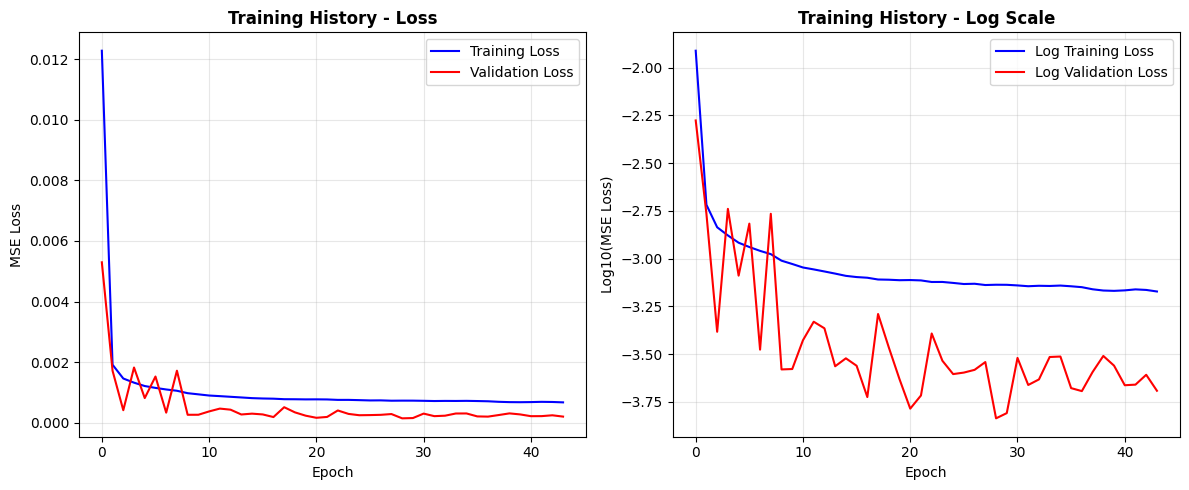

📊 Final Training Metrics:
  Final Train Loss: 0.000673
  Best Val Loss: 0.000146
  Training Epochs: 44


In [8]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('Training History - Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(np.log10(train_losses), label='Log Training Loss', color='blue')
plt.plot(np.log10(val_losses), label='Log Validation Loss', color='red')
plt.title('Training History - Log Scale', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Log10(MSE Loss)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Load best model for evaluation
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

print(f"📊 Final Training Metrics:")
print(f"  Final Train Loss: {train_losses[-1]:.6f}")
print(f"  Best Val Loss: {best_val_loss:.6f}")
print(f"  Training Epochs: {len(train_losses)}")

In [9]:
# Model evaluation and predictions
print("📊 Evaluating PyTorch LSTM Model")
print("=" * 50)

# Generate predictions on validation set
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_val_tensor)
    y_pred_scaled = y_pred_tensor.cpu().numpy()
    y_actual_scaled = y_val_tensor.cpu().numpy()

# Inverse transform predictions
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_actual_scaled)

# Calculate metrics for each feature
print("🎯 Performance Metrics:")
print("-" * 30)

metrics = {}
for i, feature in enumerate(features):
    actual = y_actual[:, i]
    pred = y_pred[:, i]
    
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    
    metrics[feature] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    
    print(f"{feature.upper():>12}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")

# Overall performance
overall_mae = np.mean([m['mae'] for m in metrics.values()])
overall_rmse = np.mean([m['rmse'] for m in metrics.values()])
overall_r2 = np.mean([m['r2'] for m in metrics.values()])

print(f"\n{'OVERALL':>12}: MAE={overall_mae:.2f}, RMSE={overall_rmse:.2f}, R²={overall_r2:.3f}")

📊 Evaluating PyTorch LSTM Model


OutOfMemoryError: CUDA out of memory. Tried to allocate 13.63 GiB. GPU 0 has a total capacity of 4.00 GiB of which 1.09 GiB is free. Of the allocated memory 2.01 GiB is allocated by PyTorch, and 106.72 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Prediction visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PyTorch LSTM Predictions vs Actual Values', fontsize=16, fontweight='bold')

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    actual = y_actual[:, i]
    pred = y_pred[:, i]
    
    # Sample for visualization if too many points
    if len(actual) > 1000:
        indices = np.random.choice(len(actual), 1000, replace=False)
        actual_sample = actual[indices]
        pred_sample = pred[indices]
    else:
        actual_sample = actual
        pred_sample = pred
    
    # Scatter plot
    ax.scatter(actual_sample, pred_sample, alpha=0.6, s=20, color='blue')
    
    # Perfect prediction line
    min_val, max_val = min(actual.min(), pred.min()), max(actual.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    # Formatting
    ax.set_xlabel(f'Actual {feature.upper()}')
    ax.set_ylabel(f'Predicted {feature.upper()}')
    ax.set_title(f'{feature.upper()} - R² = {metrics[feature]["r2"]:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Time series comparison (last 200 points)
plt.figure(figsize=(16, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    
    # Use last 200 predictions for clearer visualization
    actual_ts = y_actual[-200:, i]
    pred_ts = y_pred[-200:, i]
    time_idx = range(len(actual_ts))
    
    plt.plot(time_idx, actual_ts, label='Actual', color='blue', linewidth=2)
    plt.plot(time_idx, pred_ts, label='Predicted', color='red', linewidth=2, linestyle='--')
    
    plt.title(f'{feature.upper()} - Time Series Comparison', fontweight='bold')
    plt.xlabel('Time Steps')
    plt.ylabel(feature.replace('_', ' ').title())
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.suptitle('Last 200 Predictions vs Actual Values', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Future predictions demonstration
print("🔮 Generating Future Predictions")
print("=" * 50)

def predict_future(model, last_sequence, n_future=24, scaler_X=None, scaler_y=None):
    """Generate future predictions"""
    model.eval()
    predictions = []
    current_seq = torch.FloatTensor(last_sequence).unsqueeze(0).to(device)
    
    with torch.no_grad():
        for _ in range(n_future):
            # Predict next values
            next_pred = model(current_seq)
            predictions.append(next_pred.cpu().numpy()[0])
            
            # Update sequence for next prediction
            next_pred_expanded = next_pred.unsqueeze(1)  # Add time dimension
            current_seq = torch.cat([current_seq[:, 1:, :], next_pred_expanded], dim=1)
    
    return np.array(predictions)

# Use last sequence from validation data
last_sequence = X_val_scaled[-1]  # Last 48 hours
n_future = 48  # Predict next 48 hours

# Generate predictions
future_predictions_scaled = predict_future(model, last_sequence, n_future)
future_predictions = scaler_y.inverse_transform(future_predictions_scaled)

# Create timestamps for predictions
last_timestamp = df.index[-1]
future_timestamps = pd.date_range(
    start=last_timestamp + timedelta(hours=1),
    periods=n_future,
    freq='h'
)

# Create prediction DataFrame
future_df = pd.DataFrame(
    future_predictions,
    columns=features,
    index=future_timestamps
)

print(f"✅ Generated {n_future}-hour forecast")
print(f"Forecast period: {future_timestamps[0]} to {future_timestamps[-1]}")
print("\nForecast Summary:")
print(future_df.describe().round(2))

# Plot future predictions
plt.figure(figsize=(16, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    
    # Historical data (last 100 hours)
    historical = df[feature].tail(100)
    
    plt.plot(historical.index, historical.values, label='Historical', 
             color='blue', linewidth=2)
    plt.plot(future_df.index, future_df[feature], label='Forecast', 
             color='red', linewidth=2, linestyle='--')
    
    plt.axvline(x=last_timestamp, color='gray', linestyle=':', alpha=0.7, 
                label='Forecast Start')
    
    plt.title(f'{feature.upper()} - {n_future}h Forecast', fontweight='bold')
    plt.xlabel('Time')
    plt.ylabel(feature.replace('_', ' ').title())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

plt.suptitle('Air Quality Forecast - PyTorch LSTM GPU', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎉 PyTorch LSTM Analysis Complete!")
print(f"Model trained on {device} with {total_params:,} parameters")
print(f"Best validation R²: {overall_r2:.3f}")

🔮 Generating Future Predictions


NameError: name 'X_val_scaled' is not defined